In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.12.13


In [2]:
# Importanto Bibliotecas

import yfinance as yf
import pandas as pd
import numpy as np
import pmdarima as pm

In [1]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Flavio Renan Sant Anna" --iversions

Author: Flavio Renan Sant Anna



In [4]:
print("Recuperando os dados do Ibovespa...")

# 1. Baixamos o Ibovespa (5 anos )
df_ibov = yf.download('^BVSP', period='5y')['Close']

# 2. Aplicamos o Logaritmo para manter a escala correta
df_treino_log = np.log(df_ibov.dropna())

print("Ibovespa carregado com sucesso!")

Recuperando os dados do Ibovespa...


[*********************100%***********************]  1 of 1 completed

Ibovespa carregado com sucesso!


In [5]:
# Definimos todos os Tickers, variaveis exogenas
tickers = {
    'Dolar': 'BRL=X',        
    'SP500': '^GSPC',        
    'Shanghai': '000001.SS', # Bolsa da China
    'Petroleo': 'BZ=F',      
    'Minerio': 'TIO=F',      
    'Ouro': 'GC=F'           
}

print("Baixando as variaveis exogenas...")

Baixando as variaveis exogenas...


In [6]:
#  Baixamos os dados
df_raw = yf.download(list(tickers.values()), period='5y')['Close']
df_raw.rename(columns={v: k for k, v in tickers.items()}, inplace=True)

[*********************100%***********************]  6 of 6 completed


In [7]:
# Aplicamos o Logaritmo
df_log = np.log(df_raw)

In [8]:
# A MAGIA DO FUSO HORÁRIO: Aplicando o Lag apenas onde precisa
df_exogenas = df_log.copy()

In [9]:
# Deslocamos as variáveis ocidentais em 1 dia (Lag)
colunas_para_deslocar = ['Dolar', 'SP500', 'Petroleo', 'Minerio', 'Ouro']
df_exogenas[colunas_para_deslocar] = df_exogenas[colunas_para_deslocar].shift(1)

# A coluna 'Shanghai' fica intocada (shift 0), pois o dado de hoje já está pronto de manhã

In [10]:
# Alinhamento de Calendário com a B3
# (Certifique-se de que a variável df_treino_log já esteja carregada)
df_exogenas_treino = df_exogenas.loc[df_treino_log.index]

In [11]:
# Limpeza final de NaNs para que os tamanhos batam
df_exogenas_treino = df_exogenas_treino.dropna()
df_treino_log_alinhado = df_treino_log.loc[df_exogenas_treino.index]

print("\nDados preparados! Iniciando a Batalha do SARIMAX com 6 variáveis...\n")


Dados preparados! Iniciando a Batalha do SARIMAX com 6 variáveis...



In [12]:
import pmdarima as pm

print("Treinando o modelo ARIMA Simples (Em busca do Passeio Aleatório)...")

# Rodamos o auto_arima APENAS com o Ibovespa (sem variáveis exógenas)
modelo_arima_simples = pm.auto_arima(
    y = df_treino_log_alinhado,    # O nosso alvo: Ibovespa
    # Note que apagamos o 'X' daqui!
    start_p=1, start_q=0,
    max_p=5, max_q=5,
    d=None,                        
    seasonal=False,                
    trace=True,                    # Ligado para vermos a corrida
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n--- RESULTADO DO MODELO ARIMA SIMPLES (BASELINE) ---")
print(modelo_arima_simples.summary())

Treinando o modelo ARIMA Simples (Em busca do Passeio Aleatório)...
Performing stepwise search to minimize aic
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-6794.135, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-6794.892, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-6794.173, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-6796.004, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-6792.107, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.264 seconds

--- RESULTADO DO MODELO ARIMA SIMPLES (BASELINE) ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1120
Model:               SARIMAX(0, 1, 0)   Log Likelihood                3399.002
Date:                Sat, 16 May 2026   AIC                          -6796.004
Time:                        12:32:20   BIC                          -6790.983
Sample:                     

In [13]:
import pmdarima as pm
import pandas as pd

print("--- INICIANDO A ELIMINAÇÃO RECURSIVA (BACKWARD ELIMINATION) ---\n")

# Fazemos uma cópia para não alterar o dataset original que já está alinhado
df_exogenas_iterativo = df_exogenas_treino.copy()
limite_p_valor = 0.05
rodada = 1

while True:
    print(f"🔹 Rodada {rodada}: Treinando modelo com {len(df_exogenas_iterativo.columns)} variáveis...")
    print(f"Variáveis na arena: {list(df_exogenas_iterativo.columns)}")

    # 1. Roda o modelo (sem trace para não poluir muito a tela com milhares de linhas)
    modelo_atual = pm.auto_arima(
        y = df_treino_log_alinhado,    
        X = df_exogenas_iterativo,       
        start_p=1, start_q=0,
        max_p=5, max_q=5,
        d=None,                        
        seasonal=False,                
        trace=False,                   
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )

    # 2. Extrai todos os p-valores do modelo
    p_valores_completos = modelo_atual.arima_res_.pvalues

    # 3. Filtra apenas os p-valores das nossas variáveis exógenas
    # (Temos que ignorar o 'intercept', 'ar.L1', 'ma.L1', 'sigma2', etc.)
    p_valores_exogenas = p_valores_completos[p_valores_completos.index.isin(df_exogenas_iterativo.columns)]

    # Condição de segurança: se todas as variáveis forem eliminadas
    if p_valores_exogenas.empty:
        print("\n⚠️ Nenhuma variável externa sobreviveu ao teste rigoroso de 0.05.")
        break

    # 4. Encontra a variável com o PIOR p-valor da rodada
    pior_variavel = p_valores_exogenas.idxmax()
    pior_p_valor = p_valores_exogenas.max()

    # 5. A Guilhotina: Verifica se a pior variável precisa ser cortada
    if pior_p_valor > limite_p_valor:
        print(f"❌ '{pior_variavel}' reprovada (p-valor: {pior_p_valor:.4f}). Removendo...\n")
        # Remove a pior variável da nossa tabela para a próxima rodada
        df_exogenas_iterativo = df_exogenas_iterativo.drop(columns=[pior_variavel])
        rodada += 1
    else:
        # Se a PIOR variável tem p-valor <= 0.05, significa que TODAS passaram!
        print("\n🎉 SUCESSO! Todas as variáveis restantes foram APROVADAS!")
        break

    print(f"AIC da rodada: {modelo_atual.aic():.3f} \n")
    
# 6. Imprime o grande vencedor gerado pela automação
print("\n--- RESULTADO DO MODELO SARIMAX DEFINITIVO E AUTOMATIZADO ---")
print(modelo_atual.summary())

--- INICIANDO A ELIMINAÇÃO RECURSIVA (BACKWARD ELIMINATION) ---

🔹 Rodada 1: Treinando modelo com 6 variáveis...
Variáveis na arena: ['Shanghai', 'Dolar', 'Petroleo', 'Ouro', 'Minerio', 'SP500']
❌ 'Petroleo' reprovada (p-valor: 0.3967). Removendo...

AIC da rodada: -6378.137 

🔹 Rodada 2: Treinando modelo com 5 variáveis...
Variáveis na arena: ['Shanghai', 'Dolar', 'Ouro', 'Minerio', 'SP500']
❌ 'Dolar' reprovada (p-valor: 0.4528). Removendo...

AIC da rodada: -6772.718 

🔹 Rodada 3: Treinando modelo com 4 variáveis...
Variáveis na arena: ['Shanghai', 'Ouro', 'Minerio', 'SP500']
❌ 'Minerio' reprovada (p-valor: 0.3248). Removendo...

AIC da rodada: -6784.968 

🔹 Rodada 4: Treinando modelo com 3 variáveis...
Variáveis na arena: ['Shanghai', 'Ouro', 'SP500']
❌ 'Ouro' reprovada (p-valor: 0.8226). Removendo...

AIC da rodada: -6801.161 

🔹 Rodada 5: Treinando modelo com 2 variáveis...
Variáveis na arena: ['Shanghai', 'SP500']
❌ 'SP500' reprovada (p-valor: 0.0798). Removendo...

AIC da rodada

Baixando os dados dos últimos 12 meses...


[*********************100%***********************]  2 of 2 completed


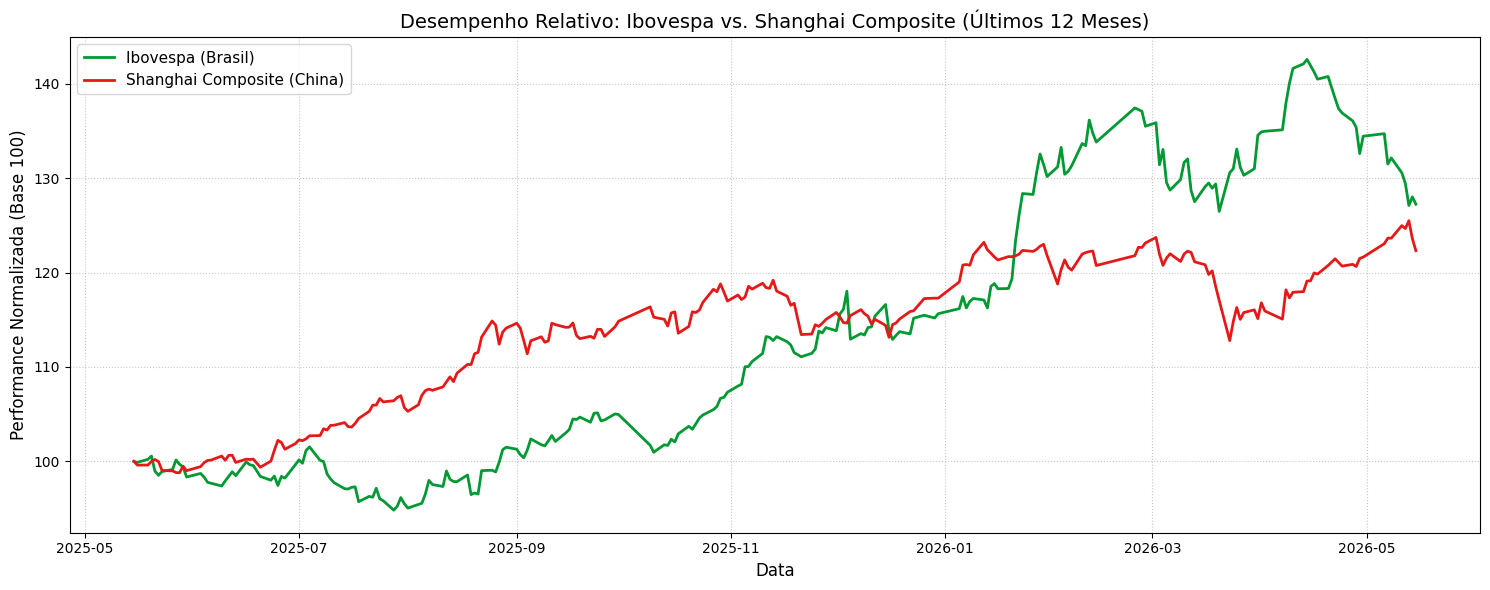

In [14]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Baixando os dados dos últimos 12 meses...")

# 1. Definir os tickers (Ibovespa e Shanghai Composite)
tickers = ['^BVSP', '000001.SS']

# 2. Baixar os dados de fechamento
df = yf.download(tickers, period='1y')['Close']

# 3. Limpeza de Calendário
# Ao usar dropna(), garantimos que o gráfico só desenhe os dias 
# em que AMBAS as bolsas abriram, alinhando as linhas perfeitamente.
df = df.dropna()

# 4. A MÁGICA DA BASE 100 (Normalização)
# Dividimos todos os dias pelo valor do dia 0 e multiplicamos por 100.
# Assim, as duas linhas partem exatamente do ponto 100 no eixo Y.
df_normalizado = (df / df.iloc[0]) * 100

# 5. Criando a "Tela" do Gráfico
plt.figure(figsize=(15, 6))

# Plotando as linhas com as cores institucionais e espessura (linewidth)
plt.plot(df_normalizado.index, df_normalizado['^BVSP'], color='#009933', linewidth=2, label='Ibovespa (Brasil)')
plt.plot(df_normalizado.index, df_normalizado['000001.SS'], color='#e61919', linewidth=2, label='Shanghai Composite (China)')

# Adicionando Títulos e Textos
plt.title('Desempenho Relativo: Ibovespa vs. Shanghai Composite (Últimos 12 Meses)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Performance Normalizada (Base 100)', fontsize=12)

# Colocando a grade de fundo (pontilhada) para facilitar a leitura dos 100 pontos
plt.grid(True, linestyle=':', alpha=0.7)

# Posicionando a legenda no canto superior esquerdo
plt.legend(loc='upper left', fontsize=11)

# Ajusta as margens para não cortar nenhuma data
plt.tight_layout()

# Mostra o gráfico na tela do seu Notebook
plt.show()
